# **Brain Tumor Detection System.**

Libraries and Tools.

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import cv2
%matplotlib inline
plt.style.use('ggplot')

from PIL import Image
from PIL import Image, ImageEnhance
from sklearn.utils import shuffle

# Keras / TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("TF version:", tf.__version__)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.19.0


In [12]:
!nvidia-smi

Sat Mar  7 19:04:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P0             29W /   70W |    3197MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Dataset.

In [15]:
#Directory for the training set
train_set='/content/drive/MyDrive/MRI Images/Training'

#Directory for the testing set
test_set='/content/drive/MyDrive/MRI Images/Testing'

###Shuffling the training data.

In [16]:
#Training data set
train_paths=[]
train_attributes=[]

for attribute in os.listdir(train_set):
  for image in os.listdir(os.path.join(train_set, attribute)):
    train_paths.append(os.path.join(train_set,attribute,image))
    train_attributes.append(attribute)

train_path, train_attributes=shuffle(train_paths,train_attributes)

In [17]:
train_path

['/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0584.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_1057.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0582.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_1191.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0567.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0653.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0442.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0067.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_1303.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_1284.jpg',
 '/content/drive/MyDrive/MRI Images/Training/pituitary/Tr-pi_1124.jpg',
 '/content/drive/MyDrive/MRI Images/Training/glioma/Tr-gl_0744.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_1285.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_1045.jpg',
 

###Shuffling the test data.

In [18]:
#Testing data set
test_paths=[]
test_attributes=[]

for attribute in os.listdir(test_set):
  for image in os.listdir(os.path.join(test_set, attribute)):
    test_paths.append(os.path.join(test_set,attribute,image))
    test_attributes.append(attribute)

test_path, test_attributes=shuffle(test_paths,test_attributes)

In [ ]:
test_path

##Data Visualization.

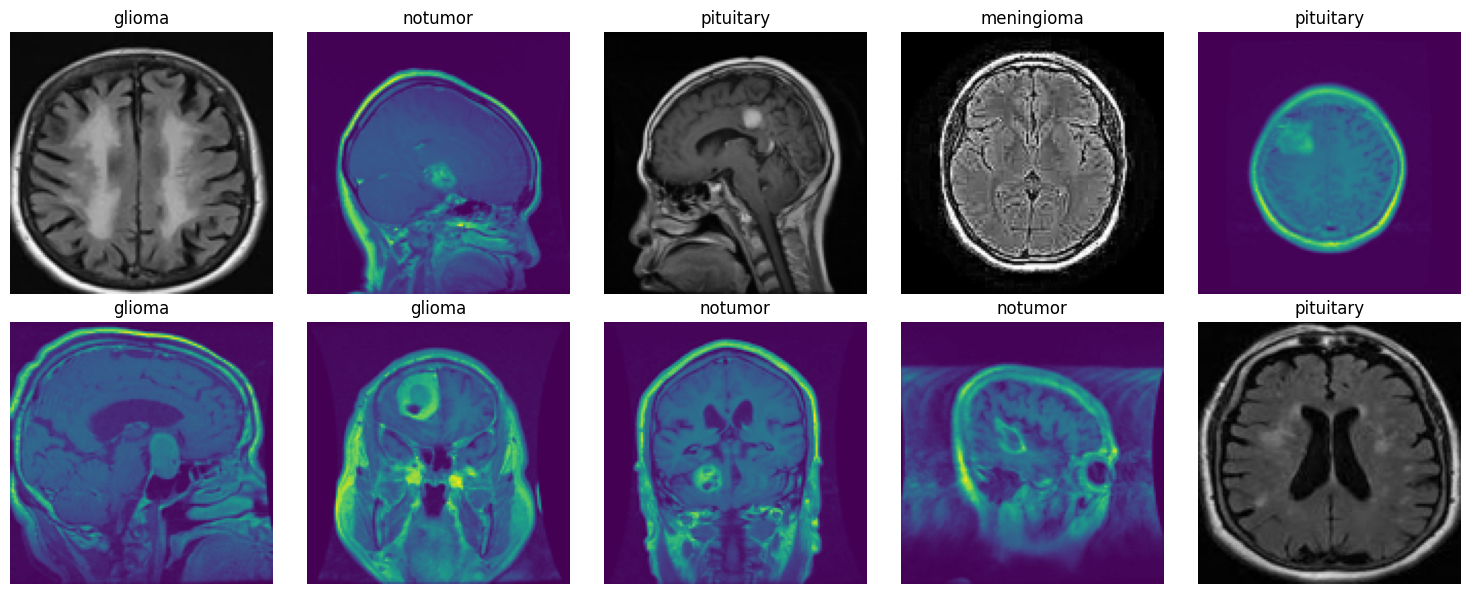

In [19]:
# Select random index for visualizing the data
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Loop through the random indices to display images
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{train_attributes[idx]}", fontsize=12)

plt.tight_layout()
plt.show()

##Image Preprocessing.




In [20]:
# Image Augmentation Function
def transform_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def load_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = transform_image(image)
        images.append(image)
    return np.array(images)

# Encode labels (Convert label names to integers)
def label_encoder(labels):
    unique_labels = os.listdir(train_set)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def batch_generator(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths  = paths[i:i + batch_size]
            batch_images = load_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = label_encoder(batch_labels)
            yield batch_images, batch_labels

##Model.

In [29]:
# Force TensorFlow to use GPU
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU configured:", gpus[0])





IMAGE_SIZE = 128

# Building CNN
model = Sequential()

model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# Fully connected layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(4, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_set,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=64,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    test_set,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=64,
    class_mode='sparse'
)

print(train_generator.class_indices)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    patience=4,
    restore_best_weights=True
)

epochs = 25

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[early_stop]
)



GPU configured: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,516,420 (32.49 MB)

 Trainable params: 8,515,972 (32.49 MB)

 Non-trainable params: 448 (1.75 KB)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 48s 426ms/step - loss: 1.4144 - sparse_categorical_accuracy: 0.5665 - val_loss: 2.0753 - val_sparse_categorical_accuracy: 0.2326
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - loss: 0.6507 - sparse_categorical_accuracy: 0.7488 - val_loss: 3.5753 - val_sparse_categorical_accuracy: 0.2654
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 351ms/step - loss: 0.5670 - sparse_categorical_accuracy: 0.7850 - val_loss: 7.1838 - val_sparse_categorical_accuracy: 0.2288
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 342ms/step - loss: 0.4878 - sparse_categorical_accuracy: 0.8169 - val_loss: 5.5942 - val_sparse_categorical_accuracy: 0.2677
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - loss: 0.4607 - sparse_categorical_accuracy: 0.8207 - val_loss: 4.3827 - val_sparse_categorical_accuracy: 0.3677
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 340ms/step - loss: 0.3956 - sparse_categorical_accuracy: 0.8497 - val_loss: 2.6593 - val_sparse_categorical_accuracy: 0.504

##Accuracy & Loss Plot.

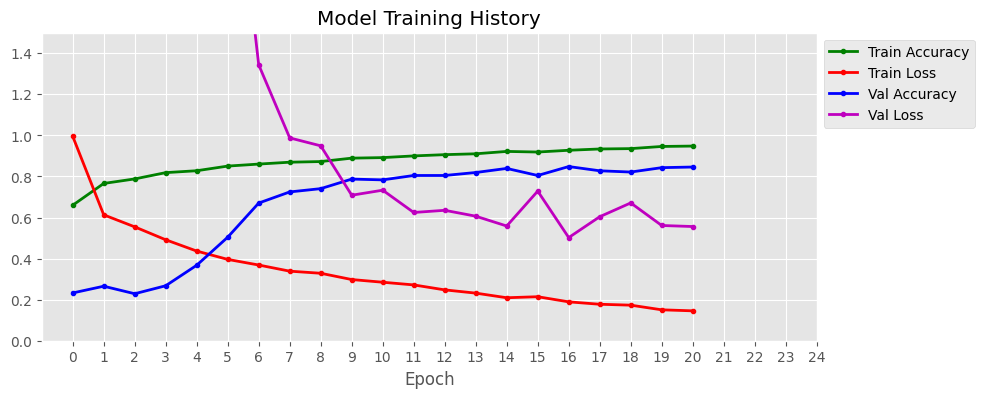

In [30]:
plt.figure(figsize=(10, 4))
plt.grid(True)

# Training
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)

# Validation
plt.plot(history.history['val_sparse_categorical_accuracy'], '.b-', linewidth=2)
plt.plot(history.history['val_loss'], '.m-', linewidth=2)

plt.title('Model Training History')
plt.xlabel('Epoch')
plt.xticks([x for x in range(epochs)])
plt.ylim(0, 1.5)
plt.legend(['Train Accuracy', 'Train Loss', 'Val Accuracy', 'Val Loss'],
           loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

##Model Classification Report.


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

#test generator
eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    test_set,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# predictions
test_predictions = model.predict(eval_generator)
predicted_labels = np.argmax(test_predictions, axis=1)
true_labels = eval_generator.classes

# Class names
class_names = list(eval_generator.class_indices.keys())

# Classification Report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

Found 1311 images belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.77      0.94      0.84       300
  meningioma       0.91      0.44      0.60       306
     notumor       0.90      0.98      0.94       405
   pituitary       0.84      1.00      0.91       300

    accuracy                           0.85      1311
   macro avg       0.86      0.84      0.82      1311
weighted avg       0.86      0.85      0.83      1311



##Confusion Matrix.

> Add blockquote




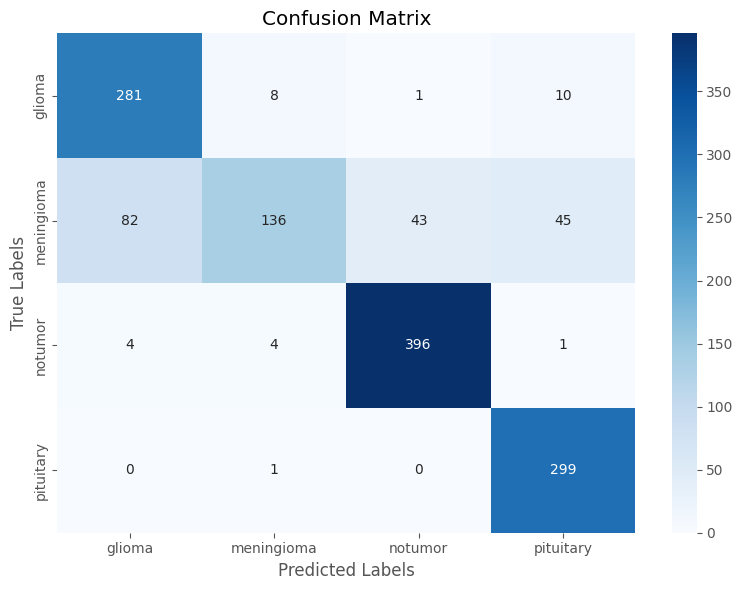

In [32]:
# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

##Saving the Notebook.

In [33]:
# Save the model to Google Drive
model.save('/content/drive/MyDrive/MRI Images/brain_tumor_cnn.h5')
print("Model saved successfully!")

Model saved successfully!
